<a href="https://colab.research.google.com/github/Abrewst/ML-repo/blob/main/assigment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload = files.upload()


Saving Housing.csv to Housing.csv


In [ ]:
import pandas as pd

In [ ]:
import io
df = pd.read_csv(io.BytesIO(upload['Housing.csv']))

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Problem 1.a (lr=0.1) — Final Parameters (theta):
[0.05909731 0.3717884  0.06986002 0.31005956 0.13830797 0.09855145]
Final Training Loss: 0.01148
Final Validation Loss: 0.01166
----------------------------------------------------
Problem 1.a (lr=0.05) — Final Parameters (theta):
[0.0702031  0.28851301 0.08527552 0.25758373 0.14823835 0.11853124]
Final Training Loss: 0.01194
Final Validation Loss: 0.01140
----------------------------------------------------
Problem 1.a (lr=0.01) — Final Parameters (theta):
[0.13582036 0.12120867 0.08869239 0.10827665 0.12303506 0.10577674]
Final Training Loss: 0.01522
Final Validation Loss: 0.01382
----------------------------------------------------


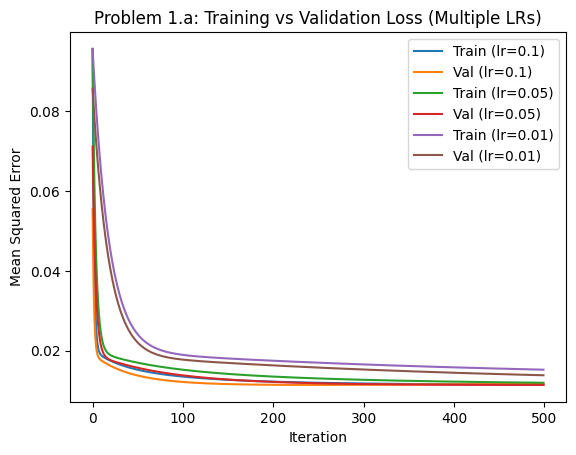

Problem 1.b (lr=0.1) — Final Parameters (theta):
[-0.00034424  0.26297592  0.0611266   0.27750804  0.10865867  0.05653189
  0.03677457  0.02571566  0.07895287  0.0779691   0.07595201  0.05476165]
Final Training Loss: 0.00866
Final Validation Loss: 0.00850
----------------------------------------------------
Problem 1.b (lr=0.05) — Final Parameters (theta):
[0.00683484 0.19946696 0.06850751 0.22759804 0.11625281 0.05800252
 0.0426964  0.02590016 0.07809682 0.0820179  0.09010509 0.05778494]
Final Training Loss: 0.00896
Final Validation Loss: 0.00834
----------------------------------------------------
Problem 1.b (lr=0.01) — Final Parameters (theta):
[0.0531267  0.07999587 0.05780611 0.09314431 0.0944869  0.06783143
 0.04665863 0.02649127 0.03978366 0.09448215 0.07558585 0.05683279]
Final Training Loss: 0.01120
Final Validation Loss: 0.00991
----------------------------------------------------


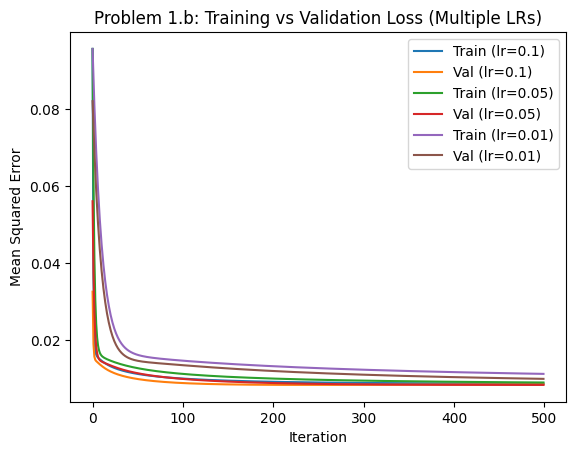

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


file_path = '/content/Housing.csv'
housing = pd.read_csv(file_path)

varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
           'airconditioning', 'prefarea']

def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

housing[varlist] = housing[varlist].apply(binary_map)

def gradient_descent(X_train, y_train, X_val, y_val, learning_rate=0.01, n_iterations=500):
    m = len(X_train)
    n_features = X_train.shape[1]


    theta = np.zeros((n_features, 1))

    train_losses = []
    val_losses = []

    for i in range(n_iterations):

        y_pred_train = X_train.dot(theta)

        gradients = (2/m) * X_train.T.dot(y_pred_train - y_train)

        theta -= learning_rate * gradients

        train_loss = (1/m) * np.sum((y_pred_train - y_train) ** 2)
        val_loss = (1/len(X_val)) * np.sum((X_val.dot(theta) - y_val) ** 2)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

def run_model(features, problem_name, learning_rates=[0.1, 0.05, 0.01], n_iter=500):

    df_train, df_val = train_test_split(housing, train_size=0.8, random_state=100)

    scaler = MinMaxScaler()
    num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking','price']
    df_train[num_vars] = scaler.fit_transform(df_train[num_vars])
    df_val[num_vars] = scaler.transform(df_val[num_vars])

    X_train = df_train[features]
    y_train = df_train['price']
    X_val = df_val[features]
    y_val = df_val['price']

    X_train_b = np.c_[np.ones((len(X_train), 1)), X_train.values]
    X_val_b = np.c_[np.ones((len(X_val), 1)), X_val.values]

    y_train = y_train.values.reshape(-1, 1)
    y_val = y_val.values.reshape(-1, 1)

    for lr in learning_rates:
        theta, train_losses, val_losses = gradient_descent(X_train_b, y_train, X_val_b, y_val,
                                                           learning_rate=lr, n_iterations=n_iter)

        plt.plot(train_losses, label=f"Train (lr={lr})")
        plt.plot(val_losses, label=f"Val (lr={lr})")

        print(f"{problem_name} (lr={lr}) — Final Parameters (theta):")
        print(theta.ravel())
        print(f"Final Training Loss: {train_losses[-1]:.5f}")
        print(f"Final Validation Loss: {val_losses[-1]:.5f}")
        print("----------------------------------------------------")

    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.title(f"{problem_name}: Training vs Validation Loss (Multiple LRs)")
    plt.show()


features_a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
run_model(features_a, "Problem 1.a", learning_rates=[0.1, 0.05, 0.01], n_iter=500)


features_b = ['area', 'bedrooms', 'bathrooms', 'stories',
              'mainroad', 'guestroom', 'basement',
              'hotwaterheating', 'airconditioning',
              'parking', 'prefarea']
run_model(features_b, "Problem 1.b", learning_rates=[0.1, 0.05, 0.01], n_iter=500)

Problem 2.a (normalize) — Final Parameters:
[2467756.47104274 3435363.72111159 1211241.57590868 2914781.18748535
 1678051.31770622 1348027.94148898]
Final Training Loss: 1590653770916.68066
Final Validation Loss: 1509221774032.36304
----------------------------------------------------
Problem 2.a (standardize) — Final Parameters:
[4795729.22018348  729932.35589789   79334.74233429  641264.73850836
  463855.866686    287331.21112434]
Final Training Loss: 1522069682826.87793
Final Validation Loss: 1596534488482.42236
----------------------------------------------------


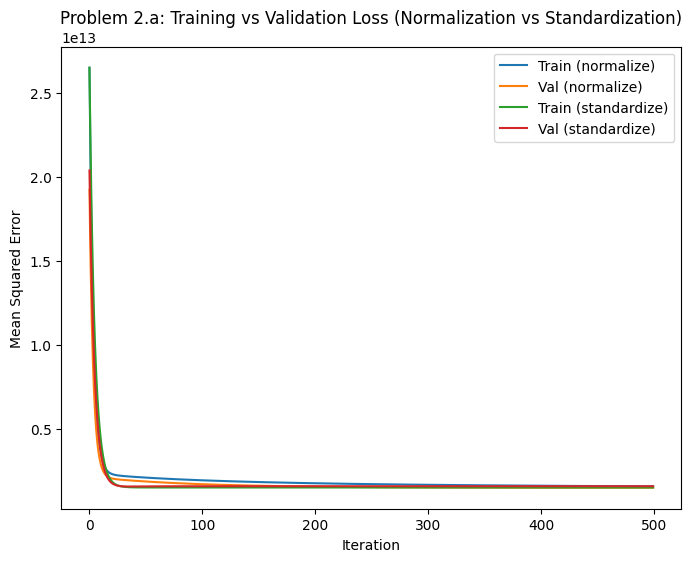

Problem 2.b (normalize) — Final Parameters:
[1701577.50816019 2352691.79607004 1045864.7296959  2588808.88645099
 1305102.13232171  713595.92188849  485360.34990496  296625.68239568
  903114.93024254  947653.71818424 1017111.33959532  660039.03689702]
Final Training Loss: 1195654775878.40747
Final Validation Loss: 1110464423603.41309
----------------------------------------------------
Problem 2.b (standardize) — Final Parameters:
[4795729.22018348  532835.69212264   72722.23633945  578491.76977424
  367612.68135752  210296.49668624  146049.33376365  145415.81416472
  204958.54052931  399907.03104326  222497.59398754  255724.44685995]
Final Training Loss: 1148468648799.61646
Final Validation Loss: 1155909646535.81616
----------------------------------------------------


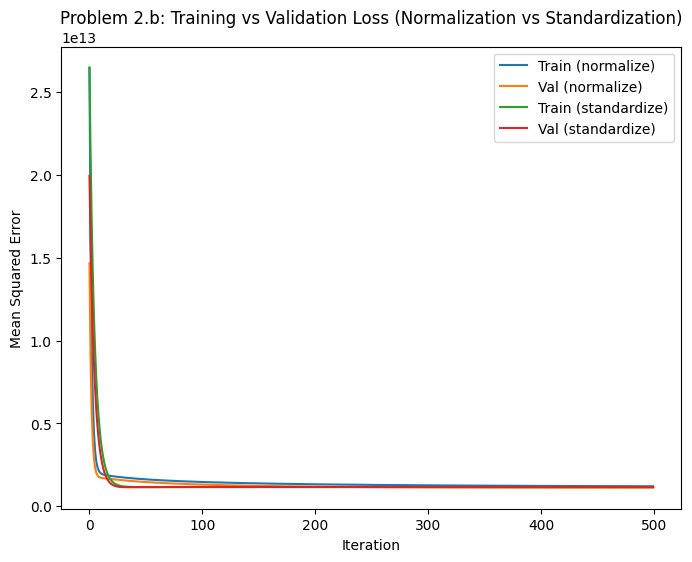

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

file_path = '/content/Housing.csv'
housing = pd.read_csv(file_path)

varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
           'airconditioning', 'prefarea']

def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

housing[varlist] = housing[varlist].apply(binary_map)


def gradient_descent(X_train, y_train, X_val, y_val, learning_rate=0.05, n_iterations=500):
    m = len(X_train)
    n_features = X_train.shape[1]

    theta = np.zeros((n_features, 1))

    train_losses = []
    val_losses = []

    for i in range(n_iterations):

        y_pred_train = X_train.dot(theta)

        gradients = (2/m) * X_train.T.dot(y_pred_train - y_train)

        theta -= learning_rate * gradients

        train_loss = (1/m) * np.sum((y_pred_train - y_train) ** 2)
        val_loss = (1/len(X_val)) * np.sum((X_val.dot(theta) - y_val) ** 2)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

def run_with_scaling(features, problem_name, scaler_type="none", lr=0.05, n_iter=500):

    df_train, df_val = train_test_split(housing, train_size=0.8, random_state=100)


    X_train = df_train[features]
    y_train = df_train['price']
    X_val = df_val[features]
    y_val = df_val['price']

    if scaler_type == "normalize":
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
    elif scaler_type == "standardize":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
    else:
        X_train = X_train.values
        X_val = X_val.values

    X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
    X_val_b = np.c_[np.ones((len(X_val), 1)), X_val]

    y_train = y_train.values.reshape(-1, 1)
    y_val = y_val.values.reshape(-1, 1)

    theta, train_losses, val_losses = gradient_descent(X_train_b, y_train, X_val_b, y_val,
                                                       learning_rate=lr, n_iterations=n_iter)

    plt.plot(train_losses, label=f"Train ({scaler_type})")
    plt.plot(val_losses, label=f"Val ({scaler_type})")

    print(f"{problem_name} ({scaler_type}) — Final Parameters:")
    print(theta.ravel())
    print(f"Final Training Loss: {train_losses[-1]:.5f}")
    print(f"Final Validation Loss: {val_losses[-1]:.5f}")
    print("----------------------------------------------------")

    return theta, train_losses, val_losses

features_a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(8,6))
run_with_scaling(features_a, "Problem 2.a", scaler_type="normalize", lr=0.05, n_iter=500)
run_with_scaling(features_a, "Problem 2.a", scaler_type="standardize", lr=0.05, n_iter=500)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("Problem 2.a: Training vs Validation Loss (Normalization vs Standardization)")
plt.legend()
plt.show()

features_b = ['area', 'bedrooms', 'bathrooms', 'stories',
              'mainroad', 'guestroom', 'basement',
              'hotwaterheating', 'airconditioning',
              'parking', 'prefarea']

plt.figure(figsize=(8,6))
run_with_scaling(features_b, "Problem 2.b", scaler_type="normalize", lr=0.05, n_iter=500)
run_with_scaling(features_b, "Problem 2.b", scaler_type="standardize", lr=0.05, n_iter=500)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("Problem 2.b: Training vs Validation Loss (Normalization vs Standardization)")
plt.legend()
plt.show()

Problem 3.a (λ=0.1, standardize) — Final Parameters:
[4795729.22018348  671746.58151628  109624.45764531  593732.92986255
  428093.14348278  282440.69413835]
Final Training Loss: 1638019095600.43774
Final Validation Loss: 1574546288495.97095
----------------------------------------------------


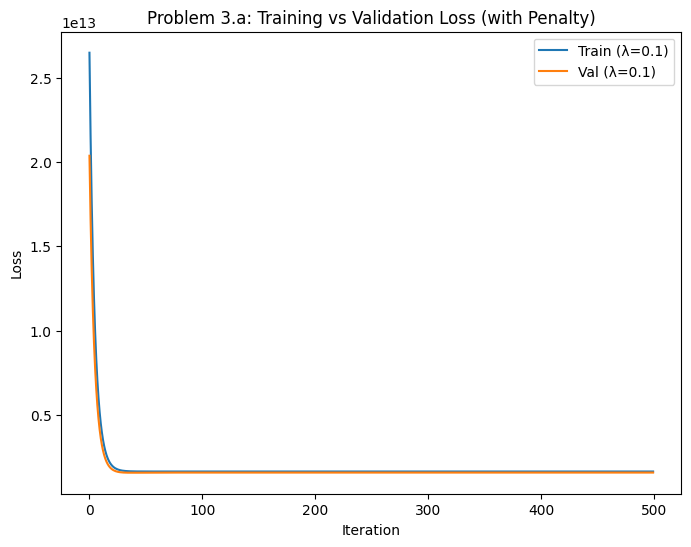

Problem 3.b (λ=0.1, standardize) — Final Parameters:
[4795729.22018348  497211.80930468   99012.1052818   536030.72938765
  343357.94438607  207788.91115249  150125.49792617  134079.88432706
  185828.02042326  380004.69629309  221761.8699366   244299.49102476]
Final Training Loss: 1258011993718.09570
Final Validation Loss: 1142695013852.29150
----------------------------------------------------


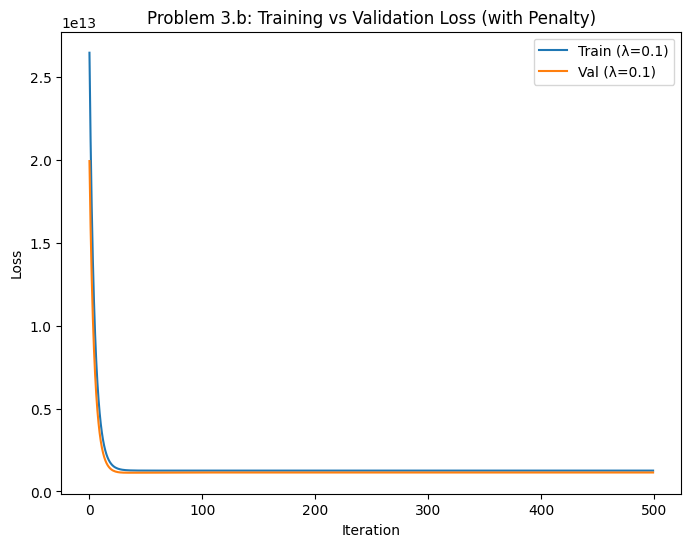

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

file_path = '/content/Housing.csv'
housing = pd.read_csv(file_path)

varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
           'airconditioning', 'prefarea']

def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

housing[varlist] = housing[varlist].apply(binary_map)

def gradient_descent_with_penalty(X_train, y_train, X_val, y_val,
                                  learning_rate=0.05, n_iterations=500, lam=0.1):
    m = len(X_train)
    n_features = X_train.shape[1]

    theta = np.zeros((n_features, 1))

    train_losses = []
    val_losses = []

    for i in range(n_iterations):

        y_pred_train = X_train.dot(theta)

        gradients = (2/m) * X_train.T.dot(y_pred_train - y_train)
        gradients[1:] += 2 * lam * theta[1:]

        theta -= learning_rate * gradients

        penalty = lam * np.sum(theta[1:] ** 2)
        train_loss = (1/m) * np.sum((y_pred_train - y_train) ** 2) + penalty

        val_loss = (1/len(X_val)) * np.sum((X_val.dot(theta) - y_val) ** 2)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

def run_with_penalty(features, problem_name, scaler_type="standardize",
                     lr=0.05, n_iter=500, lam=0.1):

    df_train, df_val = train_test_split(housing, train_size=0.8, random_state=100)

    X_train = df_train[features]
    y_train = df_train['price']
    X_val = df_val[features]
    y_val = df_val['price']

    if scaler_type == "normalize":
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
    elif scaler_type == "standardize":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
    else:
        X_train = X_train.values
        X_val = X_val.values

    X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
    X_val_b = np.c_[np.ones((len(X_val), 1)), X_val]

    y_train = y_train.values.reshape(-1, 1)
    y_val = y_val.values.reshape(-1, 1)

    theta, train_losses, val_losses = gradient_descent_with_penalty(
        X_train_b, y_train, X_val_b, y_val,
        learning_rate=lr, n_iterations=n_iter, lam=lam
    )

    plt.plot(train_losses, label=f"Train (λ={lam})")
    plt.plot(val_losses, label=f"Val (λ={lam})")

    print(f"{problem_name} (λ={lam}, {scaler_type}) — Final Parameters:")
    print(theta.ravel())
    print(f"Final Training Loss: {train_losses[-1]:.5f}")
    print(f"Final Validation Loss: {val_losses[-1]:.5f}")
    print("----------------------------------------------------")

    return theta, train_losses, val_losses

features_a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(8,6))
run_with_penalty(features_a, "Problem 3.a", scaler_type="standardize", lr=0.05, n_iter=500, lam=0.1)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Problem 3.a: Training vs Validation Loss (with Penalty)")
plt.legend()
plt.show()

features_b = ['area', 'bedrooms', 'bathrooms', 'stories',
              'mainroad', 'guestroom', 'basement',
              'hotwaterheating', 'airconditioning',
              'parking', 'prefarea']

plt.figure(figsize=(8,6))
run_with_penalty(features_b, "Problem 3.b", scaler_type="standardize", lr=0.05, n_iter=500, lam=0.1)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Problem 3.b: Training vs Validation Loss (with Penalty)")
plt.legend()
plt.show()